# Jet Clustering - La Rovere Francesco - 2164968

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
import os
import h5py
import pandas as pd
import time
import pickle

colors = ['#21918c', '#b5367a', '#d55e00', '#4b5d67', '#b58900']

In [2]:
ds = pd.read_hdf('events_anomalydetection_Z_XY_qqq.h5')

In [ ]:
#Raw dataset: 100.000 events, up to 700 products of collision
ds

,0,1,2,3,4,5,6,7,8,9,...,2091,2092,2093,2094,2095,2096,2097,2098,2099,2100
0,18.283588,-0.903479,0.060979,3.316431,-0.784941,-0.008755,9.464178,-0.812918,-0.037386,4.578035,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
1,17.661003,-0.446288,-1.379160,43.478683,-0.458125,-1.373650,208.452606,-0.455308,-1.375457,99.440353,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
2,0.624793,-0.677988,0.938955,1.265689,-1.418007,-2.987415,2.943629,-1.171538,2.927404,1.740146,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
3,0.337102,-0.576148,-1.488119,0.746461,-0.690281,-1.168585,0.822929,-0.611731,-0.854227,1.700466,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
4,0.560168,-0.426791,0.971822,0.522985,-2.214125,0.120384,1.950790,-2.105558,-0.649089,0.402474,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
99995,0.419765,-0.428561,2.483830,0.668431,-0.364857,1.689107,0.596685,-1.094639,1.496762,14.726097,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
99996,0.607786,-2.315238,-0.170871,0.361538,-0.018587,0.459475,0.748329,-0.617934,2.282426,0.364542,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
99997,0.889897,-2.390522,-0.387898,0.287380,-1.938891,1.868297,0.401675,-1.804117,1.285600,1.670041,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
99998,0.315057,-1.749749,-1.422875,2.182747,-1.920024,2.674101,0.425823,-1.260437,-0.585848,1.348121,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0


In [ ]:
#Reconstructed dataset: EventID defines the jets found in the corresponsind collision
df = pd.read_csv('ReconstructedJet.csv')
df

,EventID,pT,Eta,Phi
0,0,1218.880000,-0.757113,0.003427
1,0,608.686000,0.758360,-2.988660
2,0,385.574000,1.736260,3.090350
3,0,232.621000,0.222016,2.993640
4,0,33.210600,1.602920,-2.955370
...,...,...,...,...
25198,999,0.701401,4.284720,-2.299350
25199,999,0.651106,-4.531050,-2.008880
25200,999,0.501836,4.591800,0.772095
25201,999,0.450550,4.666060,-2.657870


/var/folders/73/kb390p311j3ctnbn_v15y42w0000gn/T/ipykernel_4266/3014043379.py:39: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = plt.cm.get_cmap('tab10', num_jets)


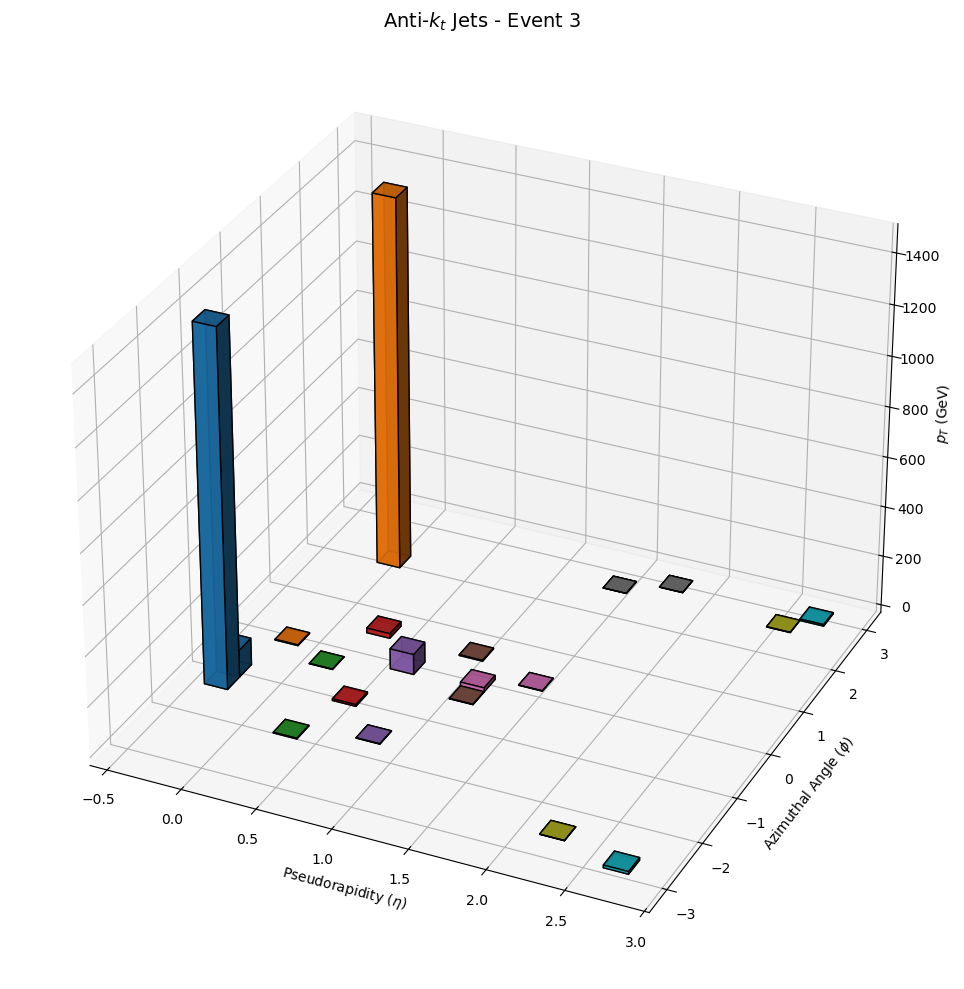

In [5]:
i = 3
event_3 = df[df['EventID'] == i]


bins = 20
hist, xedges, yedges = np.histogram2d(
   event_3['Eta'], 
   event_3['Phi'], 
   bins=bins, 
   weights=event_3['pT']
)


fig = plt.figure(figsize=(12, 10))
ax = fig.add_subplot(111, projection='3d')

#meshgrid
xpos, ypos = np.meshgrid(xedges[:-1], yedges[:-1], indexing="ij")
xpos = xpos.ravel()
ypos = ypos.ravel()

dx = (xedges[1] - xedges[0]) 
dy = (yedges[1] - yedges[0])
dz = hist.ravel() 



#Create a boolean mask where True means the bin has a jet (height > 0)
valid_mask = dz > 0
noise_mask = ~valid_mask


#Apply the valid mask so we only plot bars that actually exist
xpos_valid = xpos[valid_mask]
ypos_valid = ypos[valid_mask]
dz_valid = dz[valid_mask]
num_jets = len(dz_valid)

cmap = plt.cm.get_cmap('tab10', num_jets)
unique_colors = [cmap(i) for i in range(num_jets)]

#Plot the jets on top of the noise floor
ax.bar3d(
    xpos_valid, 
    ypos_valid, 
    np.zeros_like(dz_valid), 
    dx, 
    dy, 
    dz_valid, 
    color=unique_colors,    
    zsort='average',
    alpha=0.9,             
    edgecolor='black'      
)

ax.set_xlabel(r'Pseudorapidity ($\eta$)')
ax.set_ylabel(r'Azimuthal Angle ($\phi$)')
ax.set_zlabel(r'$p_T$ (GeV)')
ax.set_title(f'Anti-$k_t$ Jets - Event {i}', fontsize = 14)

ax.view_init(elev=30., azim=-65)

plt.tight_layout()
plt.savefig(f'Images/Jets_Event{i}.png')
plt.show()

# Serial Time Distributions:

The following plots shows the benchmark time distribution for each step of the analysis: Computing the distance is the most expensive one

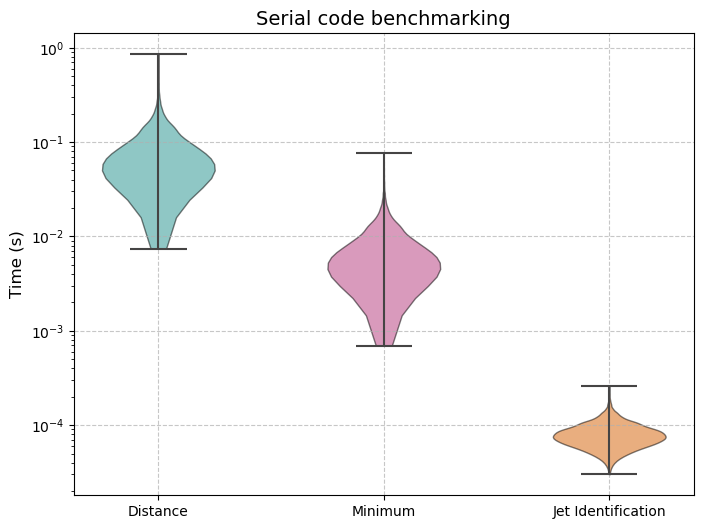

In [5]:
CollisionInfo = pd.read_csv('Benchmarking/Collision.csv')


#Distributions of single events
labels = ['Distance', 'Minimum', 'Jet Identification']


fig, ax = plt.subplots(figsize=(8, 6))

vPlot = ax.violinplot(CollisionInfo.iloc[:, 1:], showmeans=False, showmedians=False, showextrema=True)

for i, pc in enumerate(vPlot['bodies']):
   pc.set_facecolors(colors[i])
   pc.set_edgecolor('black')
   pc.set_alpha(0.5)

line_components = ['cmaxes', 'cmins', 'cbars']
for part in line_components:
    vPlot[part].set_edgecolor("#454444")
    vPlot[part].set_linewidth(1.5)

plt.yscale('log')
plt.xticks(range(1, len(labels) + 1), labels)
plt.title('Serial code benchmarking', fontsize = 14)
plt.ylabel('Time (s)', fontsize = 12)

plt.grid(linestyle='--', alpha=0.7)

plt.savefig('Images/SC_benckmarking.pdf')

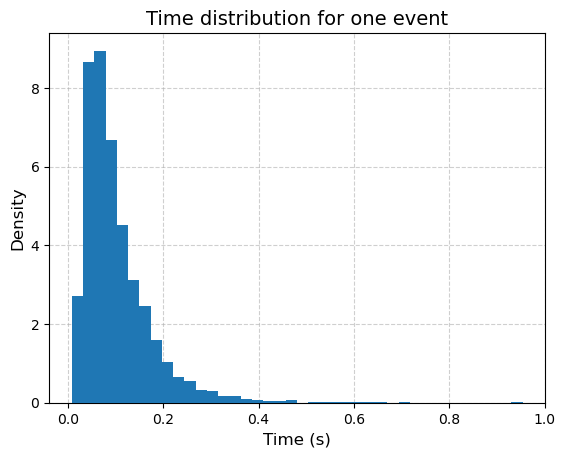

In [ ]:
#Time distribution for each event
plt.hist(CollisionInfo.iloc[:, 0], bins = 40, density = True, zorder = 100)
plt.grid(True, alpha = 0.6, linestyle = '--')

plt.xlabel("Time (s)", fontsize = 12)
plt.ylabel("Density", fontsize = 12)
plt.title("Time distribution for one event", fontsize = 14)

plt.savefig('Images/TD1Event.pdf')

# Speedup and Efficiency

Using OpenMP and therefore multiprocessing we can compute the speedup as a function of the number of cores used 

In [ ]:
!g++ Anti_kt/serialJetClustering.cpp -o serialJetClustering
!clang++ -Xpreprocessor -fopenmp -I/opt/homebrew/opt/libomp/include -L/opt/homebrew/opt/libomp/lib -lomp Anti_kt/directiveJetClustering.cpp -o directiveJetClustering

In [ ]:
AnalysisTime = {}
n = 500


#Baseline time
s = time.time()
#!./serialJetClustering {n}
e = time.time()

AnalysisTime['Baseline'] = (e-s, 0)
print(f'Baseline: {e-s} s')


#Multiprocessing time
for cores in range(2, 9):

   avgTime = []

   %env OMP_NUM_THREADS=$cores
   for i in range(10):
      # s = time.time()
      # !./directiveJetClustering {n}
      # e = time.time()
      avgTime.append(e-s)

   AnalysisTime[f'nCores={cores}'] = (np.mean(avgTime), np.std(avgTime))
   print(f'nCores = {cores}: {e-s} s')



Baseline: 51.020426988601685 s
env: OMP_NUM_THREADS=2
nCores = 2: 26.24600601196289 s
env: OMP_NUM_THREADS=3
nCores = 3: 19.220057725906372 s
env: OMP_NUM_THREADS=4
nCores = 4: 16.290276050567627 s
env: OMP_NUM_THREADS=5
nCores = 5: 14.930118799209595 s
env: OMP_NUM_THREADS=6
nCores = 6: 13.87551999092102 s
env: OMP_NUM_THREADS=7
nCores = 7: 13.14052414894104 s
env: OMP_NUM_THREADS=8
nCores = 8: 11.81397795677185 s


In [ ]:
# with open('AnalysisTime.pkl', 'wb') as f:
#    pickle.dump(AnalysisTime, f)

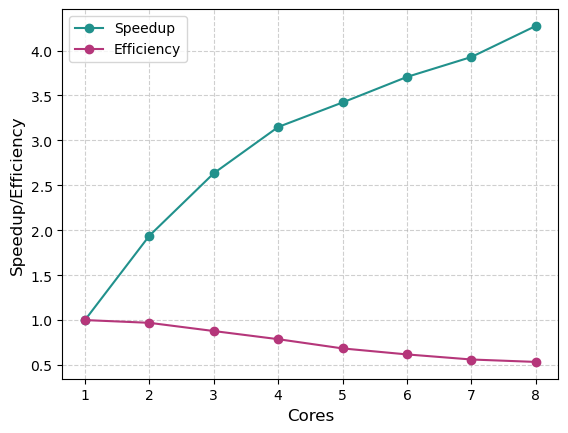

In [25]:
with open('AnalysisTime.pkl', 'rb') as f:
   AnalysisTime = pickle.load(f)


Time = np.array([list(AnalysisTime.values())[i][0] for i in range(8)])
STD  = np.array([list(AnalysisTime.values())[i][1] for i in range(8)])

sSTD = Time[0]/Time**2 * STD

nCores = np.arange(1, 9)
Speedup = Time[0]/Time
Efficiency = Speedup/nCores


plt.plot(nCores, Speedup, '-o', label='Speedup', c = '#21918c')
plt.plot(nCores, Efficiency, '-o', label = 'Efficiency', c='#b5367a')

plt.grid(True, alpha = 0.6, linestyle = '--')
plt.xlabel("Cores", fontsize = 12)
plt.ylabel("Speedup/Efficiency", fontsize = 12)
#plt.title("Speedup - Efficiency", fontsize = 14)

plt.legend()

plt.savefig('Images/SpeedUpEff.pdf')

# Time comparison between algorithms

in the following section we analyze the time and the throughput taken by the three algorithms employed, showing the immensive speedup achived by the CUDA version

In [7]:
# !g++ serialJetClustering.cpp -o serialJetClustering
#!g++ -O3 -fopenmp directiveJetClustering.cpp -o directiveJetClustering
!nvcc Anti_kt/cudaJetClustering.cu -o Anti_kt/cudaJetClustering

In [ ]:
BenchmarkTime = {
   'Serial': [],
   'Directive': [],
   'CUDA': []
}

numCollision = np.array([10, 25, 50, 75, 100, 250, 500, 750, 1000, 2500, 5000, 7500, 10000])


for n in numCollision:

   print(f'Running with N = {n} collisions')

#    s = time.time()
#    !./serialJetClustering {n}
#    e = time.time()

#    diff = e-s
#    BenchmarkTime['Serial'].append(diff)

   # s = time.time()
   # !./directiveJetClustering {n}
   # e = time.time()

   # diff = e-s
   # BenchmarkTime['Directive'].append(diff)
   
   # s = time.time()
   # !./Anti_kt/cudaJetClustering {n}
   # e = time.time()

   # diff = e-s
   # BenchmarkTime['CUDA'].append(diff)

Running with N = 10 collisions
Running with N = 25 collisions
Running with N = 50 collisions
Running with N = 75 collisions
Running with N = 100 collisions
Running with N = 250 collisions
Running with N = 500 collisions
Running with N = 750 collisions
Running with N = 1000 collisions
Running with N = 2500 collisions
Running with N = 5000 collisions
Running with N = 7500 collisions
Running with N = 10000 collisions


In [2]:
numCollision = np.array([10, 25, 50, 75, 100, 250, 500, 750, 1000, 2500, 5000, 7500, 10000])


with open('BenchmarkTime.pkl', 'rb') as f:
   BenchmarkTime = pickle.load(f)

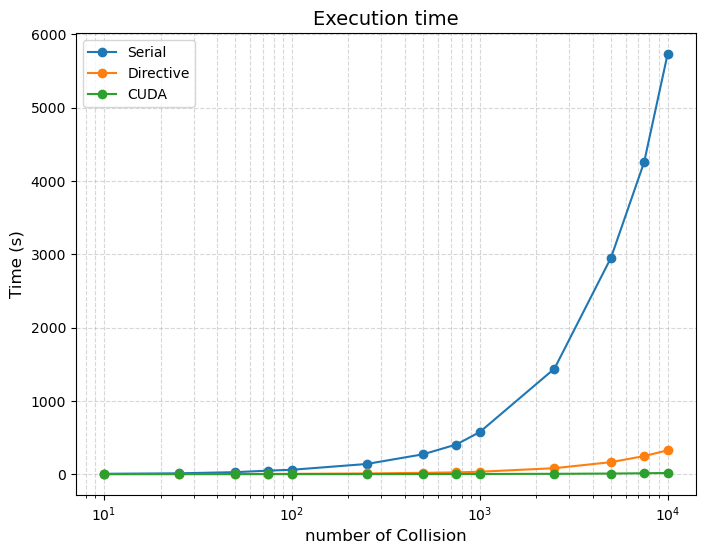

In [12]:

plt.figure(figsize = (8, 6))

plt.plot(numCollision, BenchmarkTime['Serial'], '-o', label="Serial")
plt.plot(numCollision, BenchmarkTime['Directive'], '-o', label="Directive")
plt.plot(numCollision, BenchmarkTime['CUDA'], '-o', label="CUDA")

plt.xlabel("number of Collision", fontsize = 12)
plt.ylabel("Time (s)", fontsize = 12)
plt.grid(True, alpha = 0.5, linestyle = '--', axis = 'both', which='both')

plt.title('Execution time', fontsize = 14)
#plt.yscale('log')
plt.xscale('log')
plt.legend()

plt.savefig('Time.pdf')

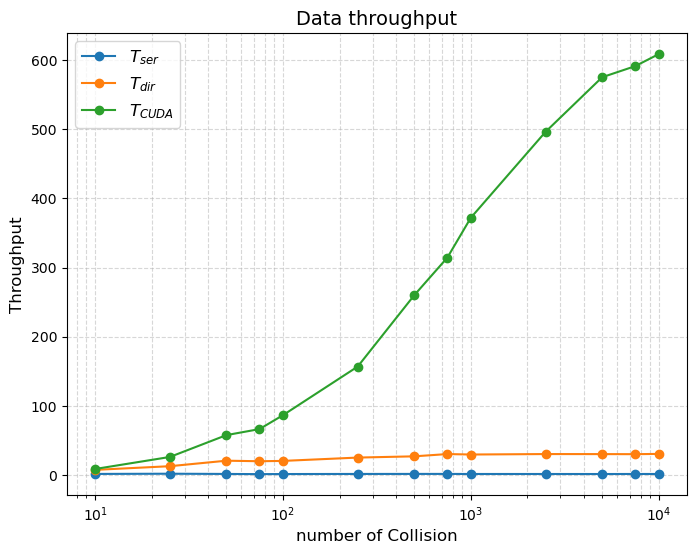

In [13]:
#Throughput:
T_serial = numCollision/BenchmarkTime['Serial']
T_dir = numCollision/BenchmarkTime['Directive']
T_CUDA = numCollision/BenchmarkTime['CUDA']


plt.figure(figsize = (8, 6))

plt.plot(numCollision, T_serial, '-o', label=r"$T_{ser}$")
plt.plot(numCollision, T_dir, '-o',label=r"$T_{dir}$")
plt.plot(numCollision, T_CUDA, '-o',label=r"$T_{CUDA}$")

plt.xlabel("number of Collision", fontsize = 12)
plt.ylabel("Throughput", fontsize = 12)
plt.title('Data throughput', fontsize = 14)


plt.grid(True, alpha = 0.5, linestyle="--", axis = 'both', which='both')

plt.xscale('log')
plt.legend(fontsize = 12)
plt.savefig('Throughput.pdf')

In [2]:
#GPU overhead benchmarking 
!nvcc Benchmarking/cudaJetClustering.cu -o Benchmarking/cudaJetClustering

In [ ]:
# #numCollision = np.array([10, 25, 50, 75, 100, 250, 500, 750, 1000, 2500, 5000, 7500, 10000])
# numCollision = np.array([25000, 50000, 75000, 100000])


# OverheadTime = {
#    'Serial': [],
#    'Directive': [],
#    'CUDA': []
# }

# for n in numCollision:
#    for _ in range(5):
#       !./Benchmarking/cudaJetClustering {n}


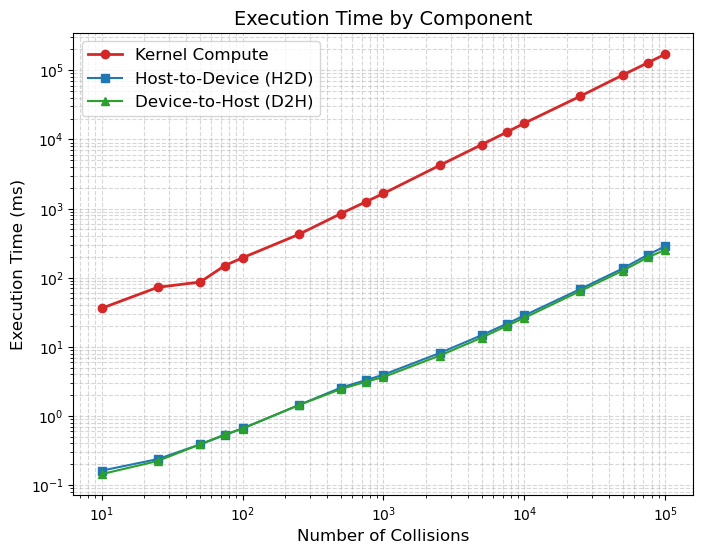

In [30]:
df = pd.read_csv('CUDA_time.csv')
numCollision = np.unique(df['NumCollisions'])

df = df.groupby('NumCollisions').mean()

plt.figure(figsize = (8, 6))

# --- Subplot 1: Log-Log Scaling Plot ---
plt.plot(numCollision, df['Time_Kernel_ms'], marker='o', label='Kernel Compute', color='tab:red', linewidth=2)
plt.plot(numCollision, df['Time_H2D_ms'], marker='s', label='Host-to-Device (H2D)', color='tab:blue')
plt.plot(numCollision, df['Time_D2H_ms'], marker='^', label='Device-to-Host (D2H)', color='tab:green')

plt.xscale('log')
plt.yscale('log')
plt.xlabel('Number of Collisions', fontsize = 12)
plt.ylabel('Execution Time (ms)', fontsize = 12)
plt.title('Execution Time by Component', fontsize = 14)
plt.grid(True, which="both", ls="--", alpha=0.5)
plt.legend(fontsize = 12)

plt.show()

## Time Complexity:

Employing an optimization version of the code we can compare the time complexity as a function of $N$ number of products of collision

In [ ]:
!g++ Anti_kt/serialJetClustering.cpp -o serialJetClustering
!g++ LinkedCell/LC_serialJC.cpp -o LC_serialJC

In [14]:
n = 20
nColl = np.arange(10, 270, 10)

# TimeComplexity = {
#    'Antik_T' : [],
#    'FastJet' : []
# }

# for c in nColl:
#    if c % 40 == 0: print(f"Analyzing {c} collision")
#    a = []
#    f = []
#    for i in range(10):

#       s = time.time()
#       !./serialJetClustering {n} {c}
#       e = time.time()
#       a.append(e-s)

#       s = time.time()
#       !./LC_serialJC {n} {c}
#       e = time.time()
#       f.append(e-s)

#    TimeComplexity['Antik_T'].append(np.mean(a))
#    TimeComplexity['FastJet'].append(np.mean(f))


In [15]:
with open('TimeComplexity.pkl', 'rb') as f:
   TimeComplexity = pickle.load(f)

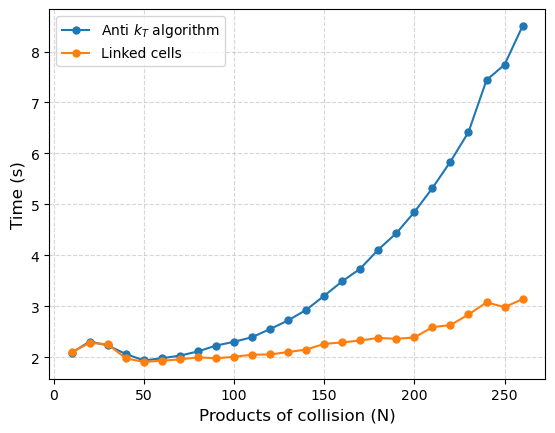

In [25]:
A_Time = np.array(TimeComplexity['Antik_T'])
F_Time = np.array(TimeComplexity['FastJet'])


#plt.figure(figsize = (8, 6))

plt.plot(nColl, A_Time, '-o', label=r"Anti $k_T$ algorithm", markersize=5)
plt.plot(nColl, F_Time, '-o', label="Linked cells", markersize=5)
plt.xlabel("Products of collision (N)", fontsize = 12)
plt.ylabel("Time (s)", fontsize = 12)

plt.grid(True, alpha = 0.5, linestyle = '--')

plt.legend()

plt.savefig('Images/Complexity.pdf')

### Total time distribution compatison

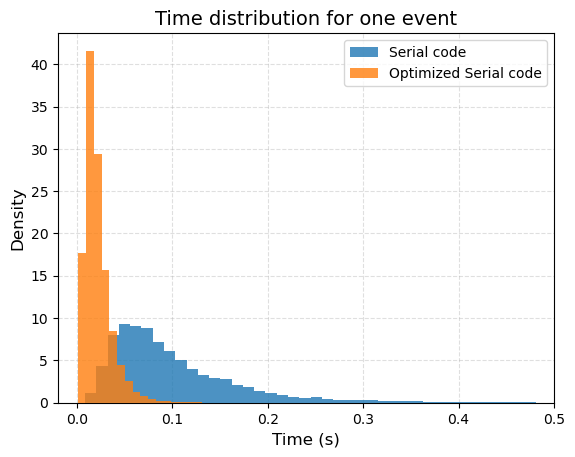

In [9]:
CollisionInfo = pd.read_csv('Benchmarking/Collision.csv')
OptCollision = pd.read_csv('Benchmarking/LC_Collision.csv')

#Time distribution for each event
plt.hist(CollisionInfo.iloc[:, 0], bins = 80, density = True, zorder = 100, alpha = 0.8, label = 'Serial code')
plt.hist(OptCollision.iloc[:, 0], bins = 20, density = True, zorder = 100, alpha = 0.8, label = "Optimized Serial code")

plt.grid(True, alpha = 0.4, linestyle = '--')

plt.xlim(-0.02, 0.5)
plt.xlabel("Time (s)", fontsize = 12)
plt.ylabel("Density", fontsize = 12)
plt.title("Time distribution for one event", fontsize = 14)
plt.legend()
#plt.savefig('Images/TD1Event.pdf')

#### Compare the throughput of the unoptimized algorithm with the optimized one

In [7]:
!g++ -O3 -fopenmp LinkedCell/LC_directiveJC.cpp -o LinkedCell/LC_directiveJC
!nvcc Anti_kt/cudaJetClustering.cu -o Anti_kt/cudaJetClustering

In [9]:
numCollision = np.array([10, 25, 50, 75, 100, 250, 500, 750, 1000, 2500, 5000, 7500, 10000, 25000, 50000, 75000, 100000])

FinalComparison = {
   'OptDir': [],
   'CUDA': []
}


for n in numCollision:

   print(f'Running with N = {n} collisions')

   s = time.time()
   !./LinkedCell/LC_directiveJC {n}
   e = time.time()

   diff = e-s
   FinalComparison['OptDir'].append(diff)

   s = time.time()
   !./Anti_kt/cudaJetClustering {n}
   e = time.time()

   diff = e-s
   FinalComparison['CUDA'].append(diff)

Running with N = 10 collisions
Running with N = 25 collisions
Running with N = 50 collisions
Running with N = 75 collisions
Running with N = 100 collisions
Running with N = 250 collisions
Running with N = 500 collisions
Running with N = 750 collisions
Running with N = 1000 collisions
Running with N = 2500 collisions
Running with N = 5000 collisions
Running with N = 7500 collisions
Running with N = 10000 collisions
Running with N = 25000 collisions
Running with N = 50000 collisions
Running with N = 75000 collisions
Running with N = 100000 collisions


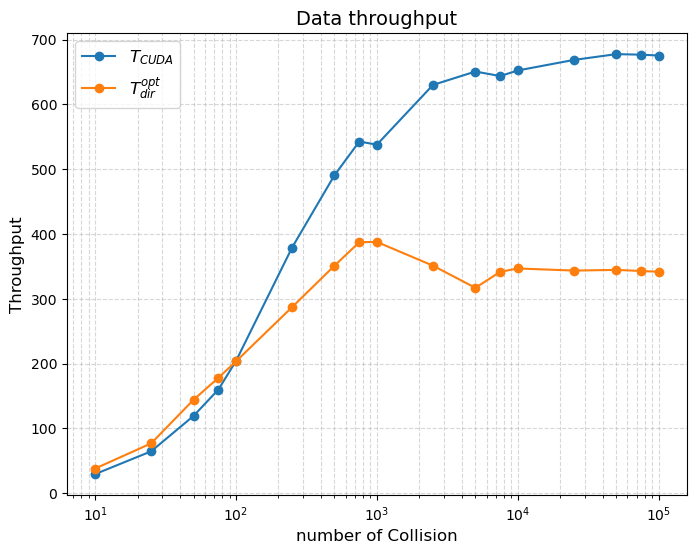

In [10]:
#Throughput:
T_CUDA = numCollision/FinalComparison['CUDA']
T_Opt_directive = numCollision/FinalComparison['OptDir']


plt.figure(figsize = (8, 6))

plt.plot(numCollision, T_CUDA, '-o',label=r"$T_{CUDA}$")
plt.plot(numCollision, T_Opt_directive, '-o',label=r"$T_{dir}^{opt}$")

plt.xlabel("number of Collision", fontsize = 12)
plt.ylabel("Throughput", fontsize = 12)
plt.title('Data throughput', fontsize = 14)


plt.grid(True, alpha = 0.5, linestyle="--", axis = 'both', which='both')

plt.xscale('log')
plt.legend(fontsize = 12)
plt.savefig('Throughput.pdf')